# 03. Modeling — 모델 개발 및 평가 (Day 2)

Day 1에서 세운 전략을 그대로 구현하고, 원논문 성능(MAPE 9.1%)과 비교한다. 학습 로직은 `src/train.py`에 있고, 이 노트북은 실행·시각화·해석을 담당한다.

| 항목 | 설정 (Day 1 근거) |
|---|---|
| 타깃 | `log10(cycle_life)` → 예측 후 10^ŷ로 되돌려 MAPE (Q1 왜도, Q3 로그-로그 선형) |
| 피처 | Selected 7개 (VIF < 10 + 세 배치 부호 일관) · 비교 : Variance 1 / Discharge 13 / Full 20 |
| 분할 | Batch 1 = Train(정책 단위 GroupKFold CV) + Valid(정책 그룹 hold-out ≈ 25%) → Batch 2 Test (Batch 3는 사용하지 않음) |
| 후보 | Linear(1) · Ridge · Lasso · **Elastic Net** · PLS · SVR · GPR · RandomForest · XGBoost |
| 선택 규칙 | ① CV MAPE 최소 ② Valid − CV > 5%p 이면 과적합으로 제외 ③ 1%p 이내면 단순한 모델 ④ Batch 2는 선택에 쓰지 않음 |

결과 : `results/model_performance.csv`(보고 포맷), `results/model_comparison.csv`, `results/03_modeling/`(그림·로그·예측값)

In [1]:
# 0. 환경 설정 — Drive에 올려둔 프로젝트 폴더에서 실행
import os, sys, subprocess
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    WORK_DIR = '/content/drive/MyDrive/취준/SKALA/데이터 분석 mini Project'
    # src/ 가 바로 들어있는 폴더를 프로젝트 루트로 사용
    PROJECT_DIR = WORK_DIR if os.path.isdir(f'{WORK_DIR}/src') else f'{WORK_DIR}/ess-battery-project'
    assert os.path.isdir(f'{PROJECT_DIR}/src'), f'src 폴더를 찾지 못했습니다 : {PROJECT_DIR}'
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', f'{PROJECT_DIR}/requirements.txt'], check=False)
else:
    PROJECT_DIR = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
os.chdir(PROJECT_DIR)
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)
print('PROJECT_DIR :', PROJECT_DIR, '| src 존재 :', os.path.isdir('src'))

Mounted at /content/drive
PROJECT_DIR : /content/drive/MyDrive/취준/SKALA/데이터 분석 mini Project/ess-battery-project | src 존재 : True


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.width', 220)
pd.set_option('display.max_colwidth', 80)

from src.utils import Reporter, BATCHES, BCOLOR, RESULTS_DIR
from src import train as T

R = Reporter('03_modeling')

## 1. 데이터 분할
같은 충전 정책의 셀은 반드시 같은 쪽에 둔다 (정책당 1~2셀이라, 나뉘면 정책 정보가 검증 쪽으로 새어 들어간다). Valid는 정책 그룹을 평균 수명 순으로 정렬해 구간마다 하나씩 뽑아, 짧은 수명과 긴 수명이 고르게 들어가도록 했다.

In [3]:
R.section('1. 데이터 분할')
F, sets = T.load_features()
train, valid = T.split_batch1(F)
R.log('피처 세트 :', {k: len(v) for k, v in sets.items()})
R.log('Selected :', sets['selected'])
parts = {'Train (B1)': train, 'Valid (B1 hold-out)': valid, 'Test (B2)': F[F.batch == 'B2']}
tbl = pd.DataFrame({k: dict(cells=len(d), policies=d.policy_base.nunique(), life_min=d.cycle_life.min(),
                            life_median=d.cycle_life.median(), life_max=d.cycle_life.max()) for k, d in parts.items()}).T
R.table(tbl, '분할 요약')
R.log('Valid 정책 :', sorted(valid.policy_base.unique()))
R.log('정책 겹침 (Train ∩ Valid) :', set(train.policy_base) & set(valid.policy_base), '← 비어 있어야 정상')


1. 데이터 분할
피처 세트 : {'variance': 1, 'discharge': 13, 'full': 20, 'full+policy': 24, 'selected': 7}
Selected : ['dq_log_var', 'dq_skew', 'dq_kurt', 'qd_slope_91_100', 'tmax_2_100', 'Q1', 'C2']

[분할 요약]
                     cells  policies  life_min  life_median  life_max
Train (B1)              29        16       599          788      1709
Valid (B1 hold-out)     12         6       534        859.5      2237
Test (B2)               39         9       392          472      1186
Valid 정책 : ['3.6C(80%)-3.6C', '5.4C(60%)-3.6C', '5.4C(80%)-5.4C', '6C(30%)-3.6C', '6C(50%)-3.6C', '6C(60%)-3C']
정책 겹침 (Train ∩ Valid) : set() ← 비어 있어야 정상


## 2. 후보 모델 학습 · 비교
모든 모델은 `결측 대치 → 표준화 → 모델` 파이프라인으로, 정책 단위 5-fold GroupKFold 격자 탐색을 한다. Linear는 Variance(1개), 나머지는 Selected(7개)로 학습하고, Elastic Net은 피처 세트 비교(Variance · Discharge · Full · Selected에서 Q1·C2 제외)도 함께 돌린다.

표의 B2 MAPE는 **보고용**이며 모델 선택에는 쓰지 않는다.

In [4]:
R.section('2. 후보 모델 비교')
res, fitted, sets = T.compare_models(F, sets, train, valid)
show = res.sort_values('cv_mape')[['model', 'feature_set', 'n_feats', 'cv_mape', 'valid_mape', 'gap_train_valid', 'B2_mape', 'params']]
R.table(show, '모델 × 피처 세트 결과 (CV 순)', fmt='{:.2f}')


2. 후보 모델 비교
Linear (1 feat)  [variance        ] CV  10.2%  Valid   8.7%  B2  26.3%
Ridge            [selected        ] CV  13.7%  Valid  11.2%  B2  37.6%
Lasso            [selected        ] CV  11.1%  Valid  10.6%  B2  31.4%
ElasticNet       [selected        ] CV  11.1%  Valid  10.2%  B2  31.0%
PLS              [selected        ] CV  13.7%  Valid  11.2%  B2  37.2%
SVR              [selected        ] CV  14.6%  Valid  13.8%  B2  39.4%
GPR              [selected        ] CV  17.0%  Valid  24.5%  B2  55.5%
RandomForest     [selected        ] CV  12.2%  Valid  21.9%  B2  41.3%
XGBoost          [selected        ] CV  15.7%  Valid  15.9%  B2  39.6%
ElasticNet       [variance        ] CV  10.1%  Valid   8.7%  B2  27.6%
ElasticNet       [discharge       ] CV   6.7%  Valid   9.5%  B2  29.4%
ElasticNet       [full            ] CV   9.6%  Valid   9.3%  B2  41.2%
ElasticNet       [selected-noQ1C2 ] CV  10.6%  Valid   9.3%  B2  29.9%

[모델 × 피처 세트 결과 (CV 순)]
              model      feature_set  n_

## 3. 최종 모델 선택
선택 규칙을 그대로 적용한다. Batch 2 열은 보지 않는다.

In [5]:
R.section('3. 최종 모델 선택')
chosen, cand = T.select_model(res)
R.log(f'규칙 ② 과적합 제외 (Valid − CV > {T.OVERFIT_GAP}%p) :',
      res[res.gap_train_valid > T.OVERFIT_GAP][['model', 'feature_set', 'gap_train_valid']].round(2).values.tolist())
R.log(f'규칙 ① CV 최소 = {cand.cv_mape.min():.2f}% → 규칙 ③ {T.TIE_MARGIN}%p 이내 후보 :',
      cand[cand.cv_mape <= cand.cv_mape.min() + T.TIE_MARGIN][['model', 'feature_set', 'cv_mape']].round(2).values.tolist())
R.log(f'\n▶ 최종 모델 : {chosen.model} / 피처 세트 {chosen.feature_set} ({chosen.n_feats}개) / 하이퍼파라미터 {chosen.params}')
entry = fitted[(chosen.model, chosen.feature_set)]
final = T.refit_full_b1(entry, F[F.batch == 'B1'])      # 하이퍼파라미터 고정, Batch 1 전체(41셀)로 재학습
coef = T.coefficients(final, entry['feats'])
if coef is not None:
    R.table(coef.to_frame('coef (표준화 피처 기준)'), '최종 모델 계수')


3. 최종 모델 선택
규칙 ② 과적합 제외 (Valid − CV > 5.0%p) : [['GPR', 'selected', 7.53], ['RandomForest', 'selected', 9.74]]
규칙 ① CV 최소 = 6.69% → 규칙 ③ 1.0%p 이내 후보 : [['ElasticNet', 'discharge', 6.69]]

▶ 최종 모델 : ElasticNet / 피처 세트 discharge (13개) / 하이퍼파라미터 {"alpha": 0.005298316906283713, "l1_ratio": 0.5}

[최종 모델 계수]
                 coef (표준화 피처 기준)
dq_log_var                 -0.144
dq_kurt                   0.01803
qd_max_minus_2           -0.01761
qd_100                    0.01011
qd_2                     0.008354
qd_int_91_100            0.002951
dq_skew                        -0
dq_log_absmin                  -0
dq_mean                         0
qd_slope_91_100                -0
qd_int_2_100                    0
qd_slope_2_100                  0
dq_2V                          -0


## 4. 성능 리포트 (Notion 포맷)
- Train : Batch 1 Train 부분의 CV 평균 MAPE
- Valid : Batch 1 hold-out MAPE (Train 부분으로 학습한 모델)
- Test : 같은 하이퍼파라미터로 **Batch 1 전체**를 다시 학습한 모델의 Batch 2 MAPE

In [6]:
R.section('4. 성능 리포트')
test = {b: T.evaluate(final, F[F.batch == b], entry['feats']) for b in ['B2']}
perf = T.performance_table(chosen.cv_mape, chosen.valid_mape, test['B2'][1])
perf.to_csv(f'{RESULTS_DIR}/model_performance.csv', index=False, encoding='utf-8-sig')
res.to_csv(f'{RESULTS_DIR}/model_comparison.csv', index=False, encoding='utf-8-sig')
R.table(perf.set_index('구분'), f'Reporting format — {chosen.model} ({chosen.feature_set})', fmt='{:.2f}')
R.log('RMSE (cycles) :', {b: round(v[2], 1) for b, v in test.items()})


4. 성능 리포트

[Reporting format — ElasticNet (discharge)]
                          MAPE (%)                   비고
구분                                                     
Train (Batch 1 CV)            6.69                     
Valid (Batch 1 Hold-out)      9.53                     
Test (Batch 2)               31.86                     
Gap (Train-Valid)             2.84         (+) : 과적합 의심
Gap (Valid-Test)             22.33  (+) : 배치간 일반화 저하 의심
Gap (Target-Test)            22.76    Target : 원논문 9.1%
RMSE (cycles) : {'B2': 228.8}


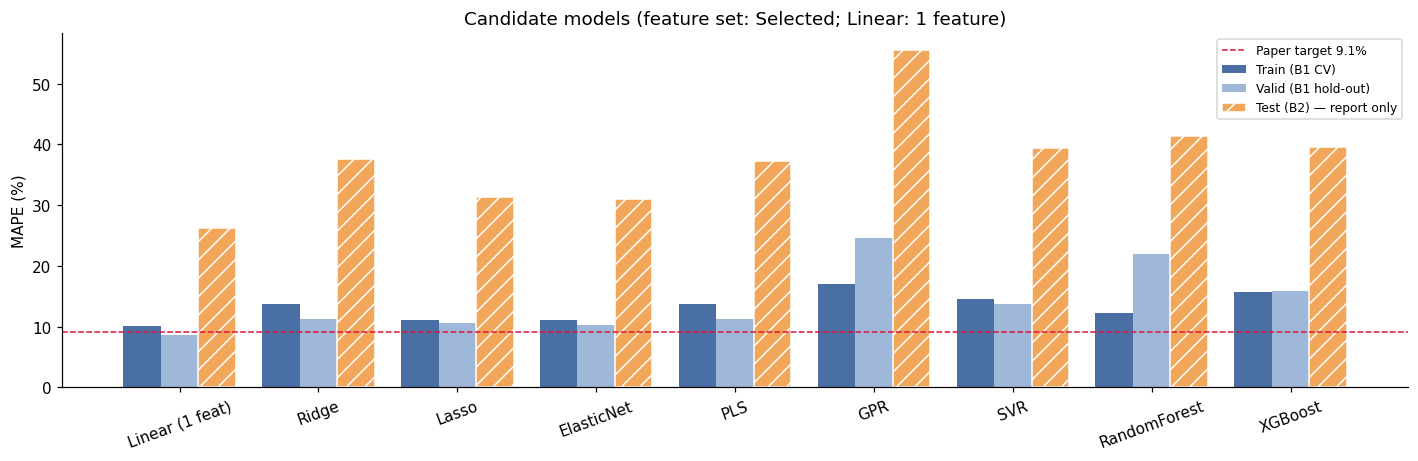

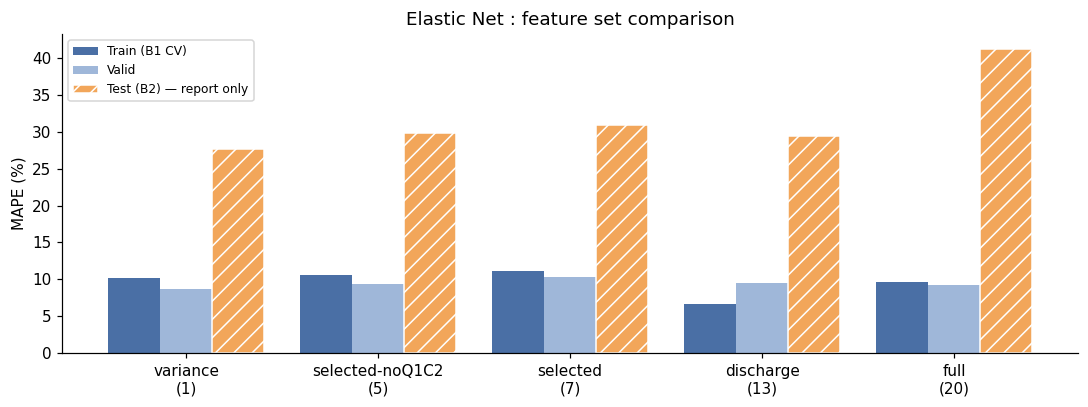

In [7]:
# 그림 1 : 모델 비교 (CV · Valid = 선택 근거 / B2 = 보고용)
main = res[(res.feature_set == 'selected') | (res.model == 'Linear (1 feat)')].copy()
main['order'] = main.model.map({m: i for i, m in enumerate(T.COMPLEXITY)})
main = main.sort_values('order')
x = np.arange(len(main)); w = .27
fig, ax = plt.subplots(figsize=(13, 4.3))
ax.bar(x - w, main.cv_mape, w, label='Train (B1 CV)', color='#4a6fa5')
ax.bar(x, main.valid_mape, w, label='Valid (B1 hold-out)', color='#9fb7d9')
ax.bar(x + w, main.B2_mape, w, label='Test (B2) — report only', color='#f2a65a', hatch='//', edgecolor='white')
ax.axhline(T.TARGET_MAPE, color='crimson', ls='--', lw=1, label=f'Paper target {T.TARGET_MAPE}%')
ax.set_xticks(x); ax.set_xticklabels(main.model, rotation=20)
ax.set(ylabel='MAPE (%)', title='Candidate models (feature set: Selected; Linear: 1 feature)'); ax.legend(fontsize=8)
plt.tight_layout(); R.savefig('M1_model_comparison')

# 그림 2 : Elastic Net 피처 세트 비교
en = res[res.model == 'ElasticNet'].sort_values('n_feats')
x = np.arange(len(en))
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.bar(x - w, en.cv_mape, w, label='Train (B1 CV)', color='#4a6fa5')
ax.bar(x, en.valid_mape, w, label='Valid', color='#9fb7d9')
ax.bar(x + w, en.B2_mape, w, label='Test (B2) — report only', color='#f2a65a', hatch='//', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels([f'{a}\n({n})' for a, n in zip(en.feature_set, en.n_feats)])
ax.set(ylabel='MAPE (%)', title='Elastic Net : feature set comparison'); ax.legend(fontsize=8)
plt.tight_layout(); R.savefig('M2_feature_set_comparison')

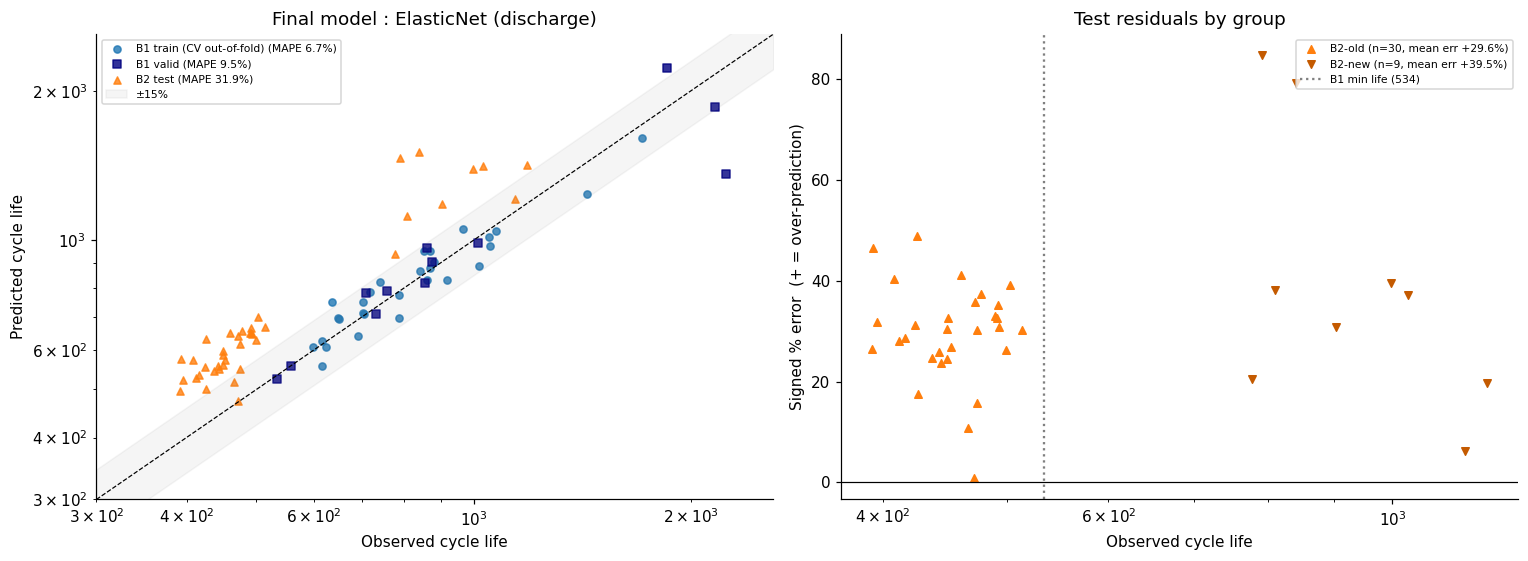

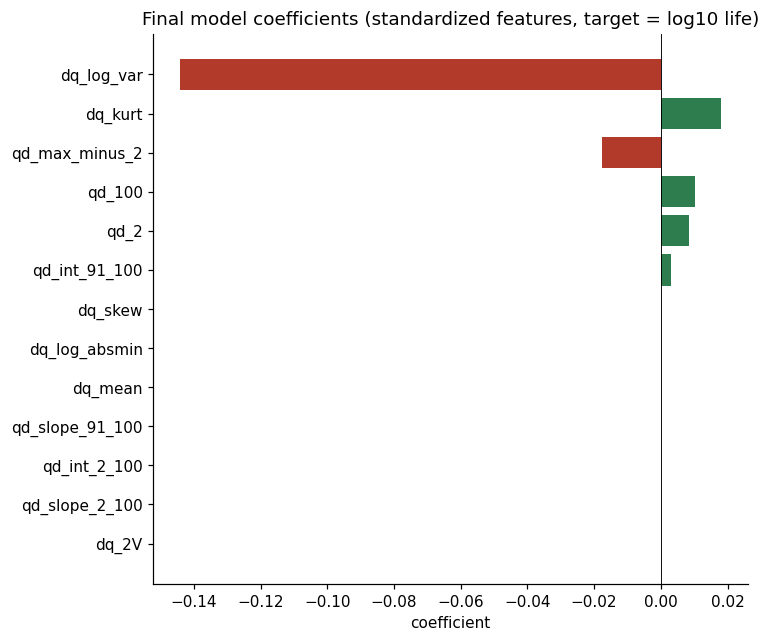

In [8]:
# 그림 3 : 예측 vs 실제 (최종 모델)
FB = F[F.batch.isin(['B1', 'B2'])]
pred = pd.DataFrame(index=FB.index)
pred['batch'], pred['structure'], pred['policy'], pred['true'] = FB.batch, FB.structure, FB.policy, FB.cycle_life
pred['split'] = np.where(FB.index.isin(train.index), 'B1 train (CV out-of-fold)',
                np.where(FB.index.isin(valid.index), 'B1 valid', 'B2 test'))
pred.loc[train.index, 'pred'] = 10 ** entry['oof']
pred.loc[valid.index, 'pred'] = T.evaluate(entry['est'], valid, entry['feats'])[0]
for b in test:
    pred.loc[pred.batch == b, 'pred'] = test[b][0]
pred['pct_err'] = (pred.pred - pred.true) / pred.true * 100
pred.to_csv(f'{R.dir}/predictions.csv', encoding='utf-8-sig')

style = {'B1 train (CV out-of-fold)': (BCOLOR['B1'], 'o'), 'B1 valid': ('navy', 's'), 'B2 test': (BCOLOR['B2'], '^')}
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
ax = axes[0]
for k, (c, m) in style.items():
    s = pred[pred.split == k]
    ax.scatter(s.true, s.pred, color=c, marker=m, s=22, alpha=.8, label=f'{k} (MAPE {T.mape(s.true, s.pred):.1f}%)')
lim = [300, 2600]; ax.plot(lim, lim, 'k--', lw=.8)
ax.fill_between(lim, [l * .85 for l in lim], [l * 1.15 for l in lim], color='gray', alpha=.08, label='±15%')
ax.set(xscale='log', yscale='log', xlim=lim, ylim=lim, xlabel='Observed cycle life', ylabel='Predicted cycle life',
       title=f'Final model : {chosen.model} ({chosen.feature_set})'); ax.legend(fontsize=7)
ax = axes[1]
b1min = F[F.batch == 'B1'].cycle_life.min()
for (b, st), mk in zip([('B2', 'old'), ('B2', 'new')], ['^', 'v']):
    s = pred[(pred.batch == b) & (pred.structure == st)]
    if len(s):
        ax.scatter(s.true, s.pct_err, color=BCOLOR[b] if st == 'old' else '#c45a00', marker=mk, s=24,
                   label=f'{b}-{st} (n={len(s)}, mean err {s.pct_err.mean():+.1f}%)')
ax.axhline(0, color='k', lw=.8); ax.axvline(b1min, color='gray', ls=':', label=f'B1 min life ({b1min:.0f})')
ax.set(xscale='log', xlabel='Observed cycle life', ylabel='Signed % error  (+ = over-prediction)', title='Test residuals by group'); ax.legend(fontsize=7)
plt.tight_layout(); R.savefig('M3_pred_vs_obs')

if coef is not None:
    fig, ax = plt.subplots(figsize=(7, max(1.8, .38 * len(coef) + 1)))
    c = coef[::-1]
    ax.barh(c.index, c.values, color=['#b23a2b' if v < 0 else '#2e7d4f' for v in c.values])
    ax.axvline(0, color='k', lw=.6); ax.set(title='Final model coefficients (standardized features, target = log10 life)', xlabel='coefficient')
    plt.tight_layout(); R.savefig('M4_coefficients')

## 5. 오류 분석
Day 1 가설 : B2 오차는 ① 학습 범위 밖(짧은 수명) ② 같은 ΔQ에서 B2 수명이 짧은 평행 이동 ③ B1에 없는 new 셀에서 생긴다. 부호 있는 오차(+ = 과대예측)로 확인한다.

In [9]:
R.section('5. 오류 분석')
grp = pred[pred.batch == 'B2'].groupby(['batch', 'structure']).agg(
    n=('true', 'size'), MAPE=('pct_err', lambda s: s.abs().mean()), mean_signed_err=('pct_err', 'mean'),
    over_pred_ratio=('pct_err', lambda s: (s > 0).mean()))
R.table(grp, '그룹별 오차 (mean_signed_err > 0 : 과대예측)', fmt='{:.2f}')
b2 = pred[pred.batch == 'B2']
inr = b2.true >= b1min
R.log(f'B2 학습 범위 안(≥{b1min:.0f}) {inr.sum()}셀 MAPE {b2[inr].pct_err.abs().mean():.1f}% | 범위 밖 {(~inr).sum()}셀 MAPE {b2[~inr].pct_err.abs().mean():.1f}%')
R.table(b2.reindex(b2.pct_err.abs().sort_values(ascending=False).index).head(8)[['structure', 'policy', 'true', 'pred', 'pct_err']],
        'B2에서 오차가 가장 큰 8셀', fmt='{:.1f}')

# 트리 모델의 범위 밖 예측 한계 확인
for name in ['RandomForest', 'XGBoost', 'ElasticNet']:
    if (name, 'selected') in fitted:
        e = fitted[(name, 'selected')]
        p = T.evaluate(T.refit_full_b1(e, F[F.batch == 'B1']), F[F.batch == 'B2'], e['feats'])[0]
        R.log(f'  {name:12s} : B2 예측 최솟값 {p.min():6.0f} (B2 실제 최솟값 {b2.true.min():.0f}, B1 최솟값 {b1min:.0f}) · '
              f'B2 short(<500) 셀 MAPE {T.mape(b2.true[b2.true < 500], p[(b2.true < 500).values]):.1f}%')


5. 오류 분석

[그룹별 오차 (mean_signed_err > 0 : 과대예측)]
                  n  MAPE  mean_signed_err  over_pred_ratio
batch structure                                            
B2    new         9 39.53            39.53             1.00
      old        30 29.56            29.56             1.00
B2 학습 범위 안(≥534) 9셀 MAPE 39.5% | 범위 밖 30셀 MAPE 29.6%

[B2에서 오차가 가장 큰 8셀]
      structure                       policy  true   pred  pct_err
cell                                                              
b2c9        new  5.6C(26%)-4.5C-newstructure 791.0 1460.3     84.6
b2c44       new    5.2C(58%)-4C-newstructure 841.0 1505.7     79.0
b2c31       old               5.6C(26%)-4.5C 425.0  632.9     48.9
b2c6        old                  3.6C(9%)-5C 393.0  575.6     46.5
b2c13       old                4.65C(69%)-6C 460.0  648.7     41.0
b2c21       old                   6C(60%)-3C 408.0  572.6     40.3
b2c45       new  5.6C(26%)-4.5C-newstructure 997.0 1390.8     39.5
b2c46       old               4.8C(

In [10]:
R.zip_and_download()

저장 : /content/drive/MyDrive/취준/SKALA/데이터 분석 mini Project/ess-battery-project/results/03_modeling.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

'/content/drive/MyDrive/취준/SKALA/데이터 분석 mini Project/ess-battery-project/results/03_modeling.zip'